# Actividad 5: M2003B
Author: A. Ramirez-Morales (andres.ramirez@tec.mx)

## Instrucciones:
- Active el kernel proveniente de `Anaconda`
- Complete las funciones donde vea líneas de código inconclusas
- Use comentarios para documentar de manera integral sus funciones
- Pruebe sus funciones con distintos parámetros
- Aumente las explicaciones en el Markdown y en el código
- Procure NO usar chatGPT ú otra tecnología similar, usted tiene la capacidad intelectual suficiente para resolverlo por usted mismo
- Use la documentación oficial de las librerías que se utilizan
- Se entrega un archivo PDF CANVAS como lo indique el profesor


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# 1. Estadística F

### Demostración de la razón de dos $\chi^2$ es una distribución de Fisher

Ejercicios:
- Describa de manera general lo que es una distribución $\chi^2$
- Describa de manera general lo que es una distribución $\chi^2$ no central
- Investigue y escriba las definiciones de la distribución Fisher
- Demuestre que la razón de dos $\chi^2$ sigue una distribución de Fisher
- Siga los "leads" del código abajo
- Justifique, con sus propias palabras, el por que es importante esta demostracion



0.5649979152752815


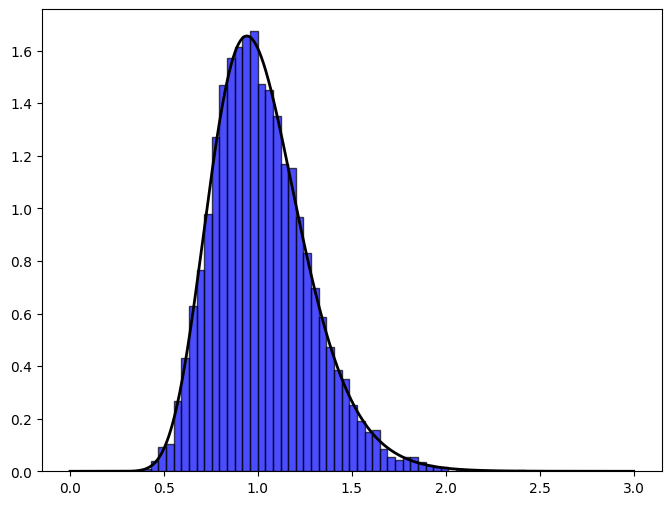

In [3]:
# paqueterias específicas
from scipy.stats import norm, chi2, t, kstest, shapiro, f
import numpy as np 
# Ejercicio: completar codigo aqui
# [Sugerencia: use np.random.chisquare()]
n = 50
num_chi2 = np.random.chisquare(df= n,size= 10000)
m = 100
den_chi2 = np.random.chisquare(df = m,size= 10000)
ratio = num_chi2/den_chi2 * (m/n)

# demostracion con p-value
# hacer prueba estadistica con kolmogorov-smirnov
resultado = kstest(ratio, f.cdf,args = (n,m)).pvalue
print(resultado)
#  interpretar los resultados anteriores


# demostracion visual
# ajustar una distribucion a F-distribution a la cantidad T
# [Sugerencia: dfn, dfd, m_loc, m_scale=f.fit(data)]
# Ejercicio: explicar cada uno de los las salidas de f.fit(data)
dfn, dfd, m_loc, m_scale= f.fit(ratio)
x = np.linspace(0, 3, 100000)
f_distr = f.pdf(x, dfn= dfn, dfd = dfd, loc = m_loc, scale = m_scale)


# graficar el histograma
plt.figure(figsize=(8, 6))
count, bins, _ = plt.hist(ratio, bins=50, density=True, alpha=0.7, color='blue', edgecolor='black')
plt.plot(x, f_distr, 'k', linewidth=2)
plt.show()

# 2. Regresion lineal multivariada (RLM)

Nuestro modelo es

$$y_i=\beta_0+\beta_1x_{i,1}+...+\beta_kx_{i,k}+\epsilon_i$$

### 2.1. Formulación matricial de RLM

Ejercicios:
- Escriba la notacion matricial de RLM
- Defina los supuestos del vector de errores
- Complete las siguientes "leads" de código
- Comienzar con el caso para $k=2$
- Cuando tenga controlado el caso anterior, consider $k=5$
- Siga los "leads" del siguiente codigo

X'X es invertible: True
1.0069409339431599 check mse


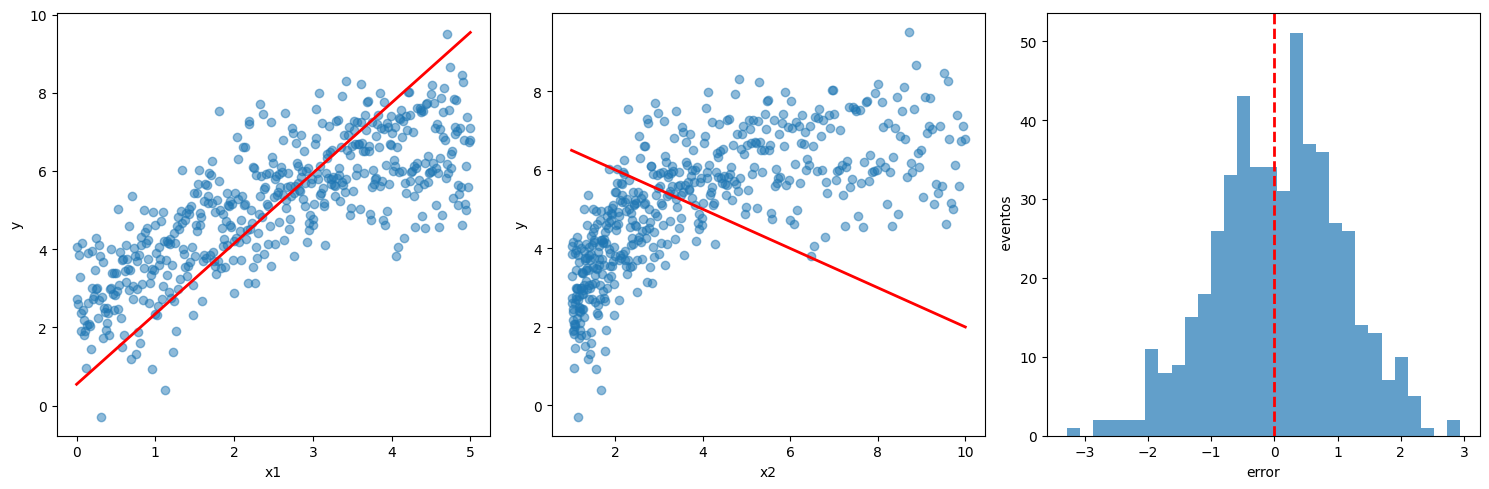

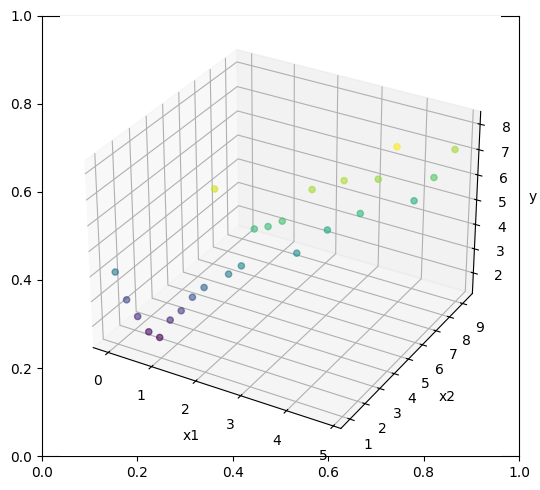

In [5]:
# aqui se empieza el codigo
n = 500
k = 2
p = k+1

# valores verdaderos
beta_0 = 2.5
beta_1 = 1.8
beta_2 = -0.5
true_beta = np.array([beta_0,beta_1,beta_2])

X1 = np.linspace(0, 5, n) 
X2 = np.logspace(0, 1, n )

# hacer la matriz X [Sugerencia: use stacks]
X_final = np.column_stack((np.ones(n),X1,X2))

# errors 
sigma = 1
epsilon = np.random.normal(loc=0,scale=sigma, size = n)

# RLM matricial, escriba RLM en forma matricial
y = X_final@true_beta + epsilon 
# print(y)

# construya la matriz X^T X
X_transpose_X = X_final.T @ X_final
#print(X_transpose_X)

# primero verificar si X^T X es invertible con el rango
rank = np.linalg.matrix_rank(X_transpose_X)
print(f"X'X es invertible: {rank == p}")

# ahora encuentre la inversa de X^T X
X_transpose_X_inv = np.linalg.inv(X_transpose_X)

# encuentra beta vector estimador
beta_hat = X_transpose_X_inv @ X_final.T @ y

# encuentre la matriz de covarianza de los estimadores
cov_beta_hat = (sigma ** 2) * X_transpose_X_inv

# encuentre los errores estandar de las b0, b1,b2
std_errors = np.sqrt(np.diag(cov_beta_hat))

# muestre que los estimadores son son no sesgados

# encuentre y estimador
y_hat = X_final @ beta_hat

# encuentre el MSE de y_hat y y medida
mse_rlm = (np.square(y - y_hat)).mean()
print(mse_rlm, "check mse")

# encuentre los elementos de la tabla de varianzas
# es decir, encuentre SSR, SSE y Syy
# enuncie una explicación integral de cada termino




# graficas
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
# x1
x1_grid = np.linspace(X1.min(), X1.max(), 100)
line_x1 = beta_0 + beta_1 * x1_grid + beta_2 * np.mean(X2)
axes[0].scatter(X1, y, alpha=0.5, label='y experimental')
axes[0].plot(x1_grid, line_x1, 'r-', linewidth=2)
axes[0].set_xlabel('x1')
axes[0].set_ylabel('y')

# x2
x2_grid = np.linspace(X2.min(), X2.max(), 100)
line_x2 = beta_0 + beta_1 * np.mean(X1) + beta_2 * x2_grid
axes[1].scatter(X2, y, alpha=0.5, label='y experimental')
axes[1].plot(x2_grid, line_x2, 'r-', linewidth=2)
axes[1].set_xlabel('x2')
axes[1].set_ylabel('y')

# error
axes[2].hist(epsilon, bins=30, alpha=0.7)
axes[2].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[2].set_xlabel('error')
axes[2].set_ylabel(' eventos')
plt.tight_layout()
plt.show()
fig.clf()

# graficar las dos variables juntas
from mpl_toolkits.mplot3d import Axes3D
fig, axes = plt.subplots(1, 1, figsize=(5.5, 5))
ax_3d = fig.add_subplot(1, 1, 1, projection='3d')
subset = slice(0, n, 20)
scatter = ax_3d.scatter(X1[subset], X2[subset], y[subset], 
                       c=y[subset], cmap='viridis', alpha=0.6)
ax_3d.set_xlabel('x1')
ax_3d.set_ylabel('x2')
ax_3d.set_zlabel('y')
plt.tight_layout()
plt.show()


### 2.2. F-estadistica de RLM como consecuencia de las $\chi^2$

Ejercicios:
- Escriba las propiedades de las $\chi^2$ que las relacionan con producto normales
- Defina lo que es una $\chi^2$ no central
- Defina lo que es idempotencia
- Complete las siguientes "leads" de código